# Proyecto Sísmico IGP: Auditoría y Exploración de Datos (EDA)

**Catálogo Sísmico del Instituto Geofísico del Perú (1960 - 2025)**

---

## Introducción y Objetivos
En este primer cuaderno desarrollaremos la **Fase 1 del Proyecto**, correspondiente a la **auditoría de calidad y análisis exploratorio de datos (EDA)**, siguiendo las metodologías y buenas prácticas vistas en las clases de Inteligencia Artificial (Cuadernos 01 y 02).

Los objetivos principales de este cuaderno son:
1. **Ingesta y Verificación de Fuentes:** Cargar el catálogo sísmico oficial y su diccionario de datos provisto por el IGP.
2. **Auditoría de Calidad:** Inspeccionar dimensiones, tipos de datos, valores nulos, registros duplicados e inconsistencias físicas.
3. **Estadística Descriptiva:** Analizar tendencias centrales, dispersión y rangos de las variables hipocentrales (magnitud, profundidad, coordenadas).
4. **Visualizaciones Exploratorias:** Generar distribuciones (histogramas y KDE), detección de valores atípicos (boxplots) y mapeo geoespacial de sismicidad en el territorio peruano.
5. **Conclusiones y Preparación:** Documentar los hallazgos para orientar la fase posterior de ingeniería de características y modelado predictivo.

## 1. Importación de Librerías

Antes de comenzar a explorar el conjunto de datos, importamos las librerías esenciales del ecosistema científico de Python:
- `pandas`: Para la carga, manipulación y auditoría tabular de datos.
- `numpy`: Para operaciones numéricas vectorizadas.
- `matplotlib.pyplot` y `seaborn`: Para la visualización estadística y representación espacial de los eventos.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 2. Carga de Datos y Diccionario Oficial

Definimos las rutas relativas hacia la carpeta `data/raw/IGP/` donde residen el archivo CSV del catálogo sísmico (con separador punto y coma `;`) y el archivo Excel con el diccionario de datos.

In [2]:
# Rutas relativas a los archivos de datos brutos
DATASET_PATH = "../data/raw/IGP/IGP_catalogo_sismico_1960_ 2025_Dataset.csv"
DICCIONARIO_PATH = "../data/raw/IGP/IGP_catalogo_sismicos_desde_1960_ DiccionarioDatos.xlsx"

# Cargar dataset de sismos
df_sismos = pd.read_csv(DATASET_PATH, sep=";")
print("✓ Catálogo sísmico cargado exitosamente.")

# Cargar diccionario de datos
df_diccionario = pd.read_excel(DICCIONARIO_PATH)
print("✓ Diccionario de datos cargado exitosamente.")

✓ Catálogo sísmico cargado exitosamente.
✓ Diccionario de datos cargado exitosamente.


### Inspección del Diccionario de Datos del IGP

Revisamos la definición oficial de cada campo para asegurar la correcta interpretación de los datos:

In [3]:
# Mostramos el contenido del diccionario de datos
display(df_diccionario.dropna(how="all"))

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,Nombre del Dataset:,Catalogo Sismico 1960 - 2023,NaN,NaN,NaN
2,Variable,Descripción,Tipo de dato,Tamaño,Información Adicional
3,FECHA_CORTE,Fecha de corte de información,Numérico,8,Formato: aaaammdd
4,FECHA_UTC,"Hora universal coordinado (UTC), Es la fecha c...",Numérico,8,Formato: aaaammdd
5,HORA_UTC,"Hora universal coordinada (UTC), cinco horas a...",Numérico,6,Formato: hhmmss
6,LATITUD,"Es la distancia en grados, minutos y segundos ...",Float,NaN,NaN
7,LONGITUD,"Es la distancia en grados, minutos y segundos ...",Float,NaN,NaN
8,PROFUNDIDAD,Profundidad del foco sísmico por debajo de la ...,Numérico,NaN,NaN
9,MAGNITUD,Corresponde a la cantidad de energía liberada ...,Float,NaN,NaN


## 3. Exploración Inicial y Dimensiones del Dataset

Verificamos el volumen total de observaciones y las variables disponibles utilizando `shape`, así como un primer y último vistazo con `head()` y `tail()`.

In [4]:
# Dimensiones del DataFrame
filas, columnas = df_sismos.shape
print(f"Total de registros (sismos registrados): {filas:,}")
print(f"Total de variables (columnas): {columnas}")

print("\nPrimeras 5 observaciones:")
display(df_sismos.head())

print("\nÚltimas 5 observaciones:")
display(df_sismos.tail())

Total de registros (sismos registrados): 24,289
Total de variables (columnas): 8

Primeras 5 observaciones:


,ID,FECHA_UTC,HORA_UTC,LATITUD,LONGITUD,PROFUNDIDAD,MAGNITUD,FECHA_CORTE
0,0,19600113,154034,-16.145,-72.144,60,7.5,20223006
1,1,19600115,93024,-15.000,-75.000,70,7.0,20223006
2,2,19600117,25758,-14.500,-74.500,150,6.4,20223006
3,3,19600123,33732,-12.500,-68.500,300,5.8,20223006
4,4,19600130,50724,-5.500,-77.500,100,5.7,20223006



Últimas 5 observaciones:


,ID,FECHA_UTC,HORA_UTC,LATITUD,LONGITUD,PROFUNDIDAD,MAGNITUD,FECHA_CORTE
24284,24284,20251230,122231,-8.99,-79.24,48,4.1,20260528
24285,24285,20251230,161120,-8.38,-75.07,119,4.4,20260528
24286,24286,20251230,232830,-17.69,-70.66,15,3.7,20260528
24287,24287,20251231,12816,-9.83,-75.56,13,3.5,20260528
24288,24288,20251231,203441,-12.89,-76.85,51,3.9,20260528


### Interpretación Inicial de la Estructura
- El dataset cubre un registro histórico extenso desde 1960 hasta 2025 con más de 24,000 eventos sísmicos registrados.
- Cada fila representa un evento sísmico individual caracterizado por su identificación (`ID`), momento temporal (`FECHA_UTC`, `HORA_UTC`), ubicación espacial (`LATITUD`, `LONGITUD`, `PROFUNDIDAD`), magnitud calculada (`MAGNITUD`) y fecha de corte de la base de datos (`FECHA_CORTE`).

## 4. Tipos de Datos y Calidad de la Información

Examinamos los tipos de datos asociados a cada columna con `info()` y evaluamos si existen valores faltantes (`nulos`) o duplicados exactos.

In [5]:
# Información técnica del DataFrame
print("Estructura técnica de tipos de datos:")
df_sismos.info()

Estructura técnica de tipos de datos:
<class 'pandas.DataFrame'>
RangeIndex: 24289 entries, 0 to 24288
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           24289 non-null  int64  
 1   FECHA_UTC    24289 non-null  int64  
 2   HORA_UTC     24289 non-null  int64  
 3   LATITUD      24289 non-null  float64
 4   LONGITUD     24289 non-null  float64
 5   PROFUNDIDAD  24289 non-null  int64  
 6   MAGNITUD     24289 non-null  float64
 7   FECHA_CORTE  24289 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 1.5 MB


In [6]:
# Auditoría de valores nulos
nulos = df_sismos.isna().sum()
pct_nulos = (df_sismos.isna().mean() * 100).round(2)
tabla_calidad = pd.DataFrame({
    "Tipo de Dato": df_sismos.dtypes,
    "Valores Nulos": nulos,
    "% Faltante": pct_nulos
})

print("Tabla de auditoría de completitud y tipos:")
display(tabla_calidad)

# Auditoría de duplicados
total_duplicados = df_sismos.duplicated().sum()
print(f"\nCantidad total de filas duplicadas exactas: {total_duplicados}")

Tabla de auditoría de completitud y tipos:


,Tipo de Dato,Valores Nulos,% Faltante
ID,int64,0,0.0
FECHA_UTC,int64,0,0.0
HORA_UTC,int64,0,0.0
LATITUD,float64,0,0.0
LONGITUD,float64,0,0.0
PROFUNDIDAD,int64,0,0.0
MAGNITUD,float64,0,0.0
FECHA_CORTE,int64,0,0.0



Cantidad total de filas duplicadas exactas: 0


### Interpretación de Calidad de Datos
- **Completitud:** Las columnas numéricas hipocentrales (`LATITUD`, `LONGITUD`, `PROFUNDIDAD`, `MAGNITUD`) presentan **0% de valores nulos**, lo que garantiza una base sólida para el modelado matemático.
- **Duplicados:** No se registran filas duplicadas exactas.
- **Oportunidad de preprocesamiento:** `FECHA_UTC` y `HORA_UTC` están almacenadas como enteros numéricos (`int64`). En la siguiente fase de ingeniería de características, convendrá parsearlas a objetos de tipo fecha/hora (`datetime`) para extraer componentes estacionales o temporales.

## 5. Resumen Estadístico Descriptivo

Utilizamos `describe()` para analizar las medidas de tendencia central (media, mediana), dispersión (desviación estándar) y los percentiles de las variables numéricas.

In [7]:
# Resumen descriptivo de parámetros físicos y geográficos
variables_fisicas = ["LATITUD", "LONGITUD", "PROFUNDIDAD", "MAGNITUD"]
print("Estadísticas descriptivas de los parámetros sísmicos:")
display(df_sismos[variables_fisicas].describe().round(3))

Estadísticas descriptivas de los parámetros sísmicos:


,LATITUD,LONGITUD,PROFUNDIDAD,MAGNITUD
count,24289.000,24289.000,24289.000,24289.000
mean,-11.375,-75.704,70.764,4.705
std,4.480,3.097,65.927,0.452
min,-23.397,-82.894,0.000,3.000
25%,-15.380,-77.767,29.000,4.500
50%,-11.724,-75.745,48.000,4.700
75%,-7.926,-73.601,106.000,4.900
max,-1.490,-66.981,743.000,8.400


### Interpretación de las Estadísticas Descriptivas
- **Magnitud:** Presenta una media cercana a **4.5** con un rango que va desde eventos menores (~3.0 o menores) hasta sismos de gran magnitud (**8.0 o superiores**). El 50% de los sismos registrados se concentra entre magnitudes 4.1 y 4.8.
- **Profundidad:** La mediana se ubica en torno a profundidades intermedias (~33 - 50 km), pero con un máximo superior a los 600 km, lo que refleja sismos profundos típicos del proceso de subducción de la Placa de Nazca bajo la Placa Sudamericana.
- **Coordenadas:** Las latitudes y longitudes concuerdan con la extensión territorial del Perú y su margen oceánico adyacente (Latitud aprox. -20° a 0°, Longitud aprox. -85° a -68°).

## 6. Visualizaciones Exploratorias: Distribuciones y Outliers

Siguiendo las técnicas del Cuaderno 02 de la clase, examinamos la forma de las distribuciones y los valores atípicos mediante histogramas con estimación de densidad por kernel (KDE) y diagramas de caja (boxplots).

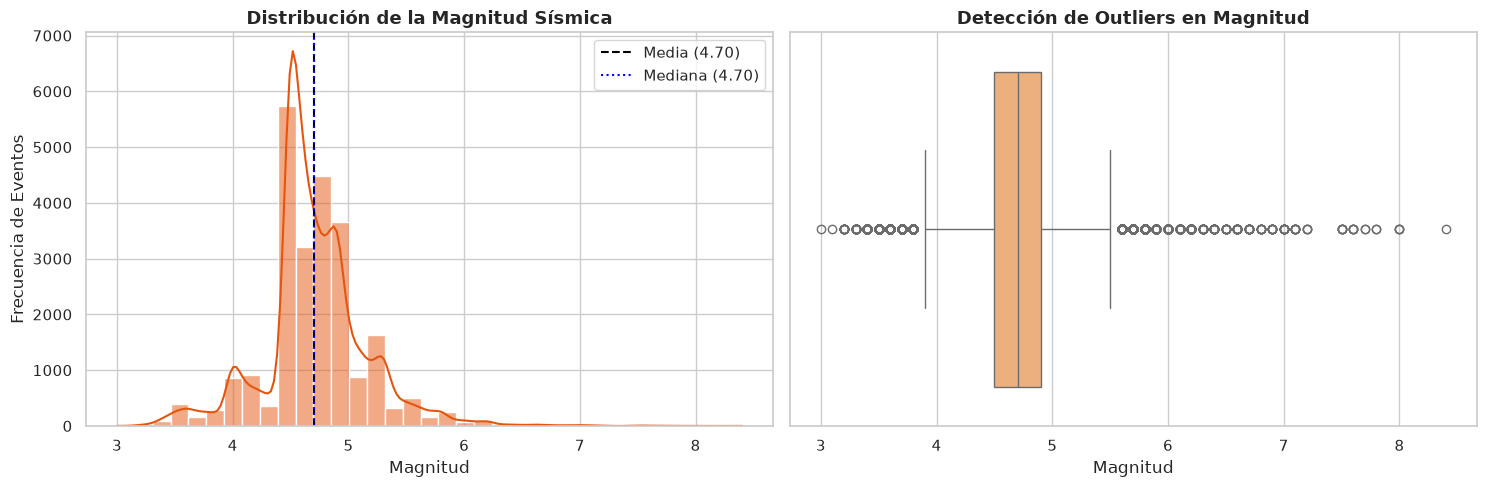

In [8]:
# Visualización de la distribución y dispersión de la Magnitud
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma + KDE
sns.histplot(df_sismos["MAGNITUD"], kde=True, bins=35, color="#e6550d", ax=axes[0])
axes[0].set_title("Distribución de la Magnitud Sísmica", fontsize=13, weight="bold")
axes[0].set_xlabel("Magnitud")
axes[0].set_ylabel("Frecuencia de Eventos")
axes[0].axvline(df_sismos["MAGNITUD"].mean(), color="black", linestyle="--", label=f"Media ({df_sismos['MAGNITUD'].mean():.2f})")
axes[0].axvline(df_sismos["MAGNITUD"].median(), color="blue", linestyle=":", label=f"Mediana ({df_sismos['MAGNITUD'].median():.2f})")
axes[0].legend()

# Boxplot para outliers
sns.boxplot(x=df_sismos["MAGNITUD"], color="#fdae6b", ax=axes[1])
axes[1].set_title("Detección de Outliers en Magnitud", fontsize=13, weight="bold")
axes[1].set_xlabel("Magnitud")

plt.tight_layout()
plt.show()

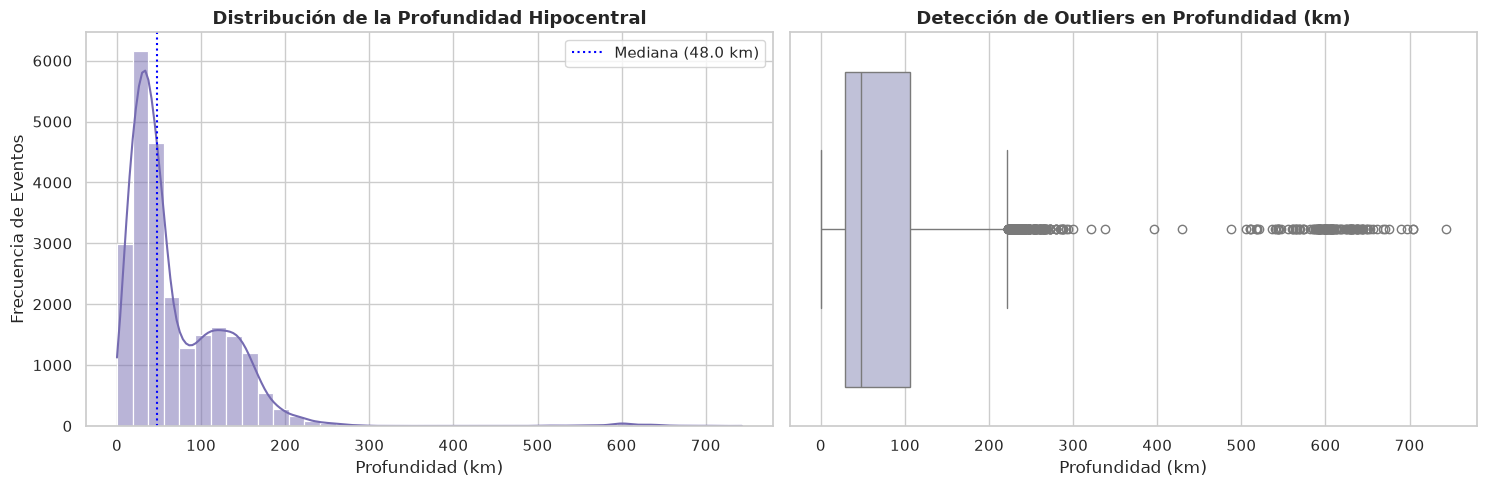

In [9]:
# Visualización de la distribución y dispersión de la Profundidad
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma + KDE
sns.histplot(df_sismos["PROFUNDIDAD"], kde=True, bins=40, color="#756bb1", ax=axes[0])
axes[0].set_title("Distribución de la Profundidad Hipocentral", fontsize=13, weight="bold")
axes[0].set_xlabel("Profundidad (km)")
axes[0].set_ylabel("Frecuencia de Eventos")
axes[0].axvline(df_sismos["PROFUNDIDAD"].median(), color="blue", linestyle=":", label=f"Mediana ({df_sismos['PROFUNDIDAD'].median():.1f} km)")
axes[0].legend()

# Boxplot para outliers
sns.boxplot(x=df_sismos["PROFUNDIDAD"], color="#bcbddc", ax=axes[1])
axes[1].set_title("Detección de Outliers en Profundidad (km)", fontsize=13, weight="bold")
axes[1].set_xlabel("Profundidad (km)")

plt.tight_layout()
plt.show()

### Interpretación de Distribuciones y Outliers
- **Asimetría positiva en Magnitud:** La gran mayoría de eventos se concentran en magnitudes moderadas (4.0 a 5.0). Los sismos mayores a 6.5 aparecen como valores atípicos (outliers) superiores en el boxplot, lo cual es físicamente natural según la ley de Gutenberg-Richter (los sismos de gran energía son mucho menos frecuentes pero de alto impacto).
- **Distribución bimodal/multimodal en Profundidad:** Se aprecia un grupo muy denso de sismos superficiales (0 a 60 km, típicos de la zona costera y de intraplaca) y una cola prolongada hacia sismos muy profundos (> 500 km) en la zona de la selva / frontera este.

## 7. Mapeo Espacial de la Sismicidad en el Perú

Representamos gráficamente la posición geográfica de los eventos (`LONGITUD` vs `LATITUD`) mapeando además la magnitud y profundidad mediante tamaño y color de los marcadores.

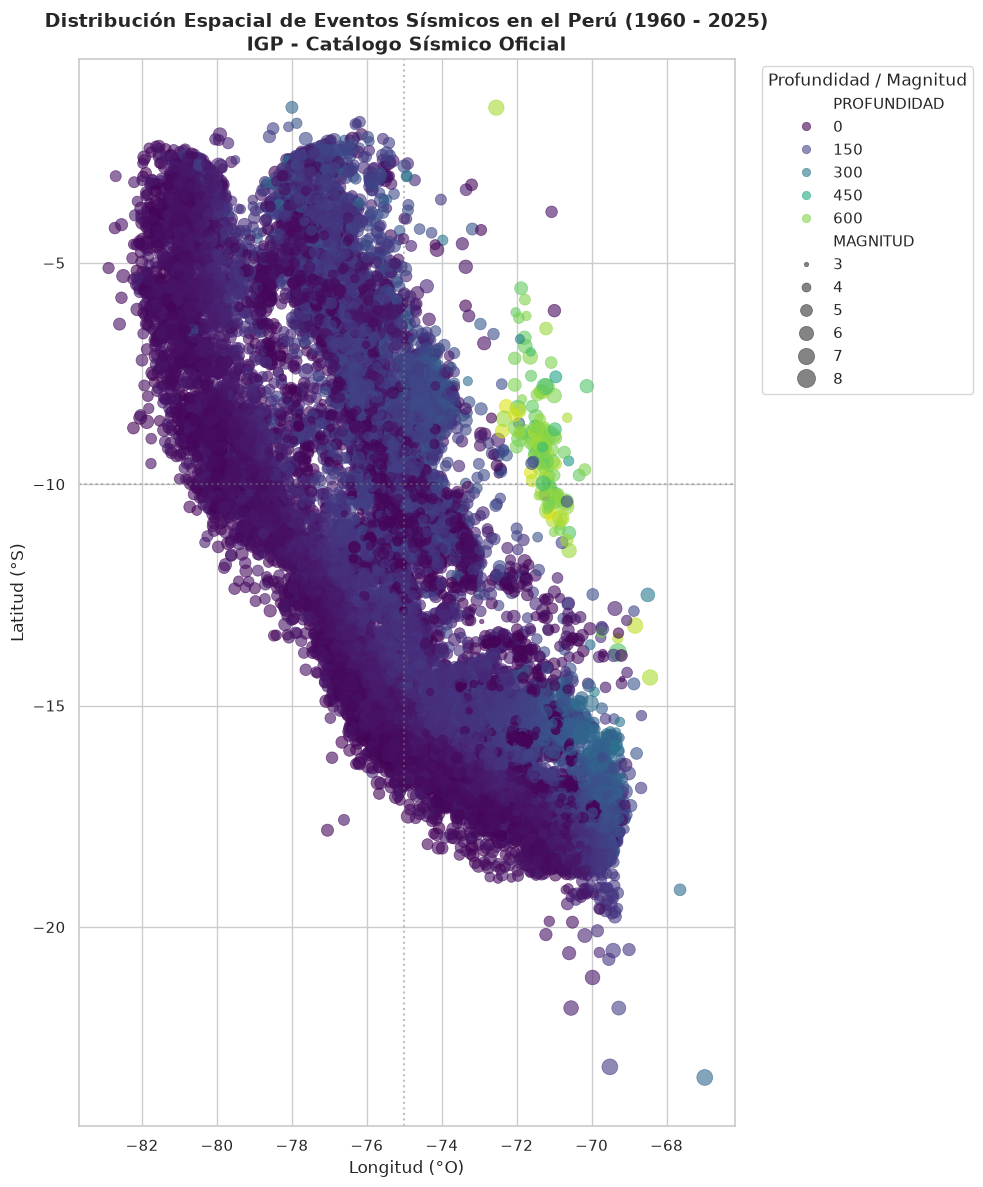

In [10]:
# Mapa geoespacial de dispersión de sismos
plt.figure(figsize=(10, 12))

scatter = sns.scatterplot(
    data=df_sismos,
    x="LONGITUD",
    y="LATITUD",
    hue="PROFUNDIDAD",
    size="MAGNITUD",
    palette="viridis",
    sizes=(10, 180),
    alpha=0.6,
    edgecolor=None
)

plt.title("Distribución Espacial de Eventos Sísmicos en el Perú (1960 - 2025)\nIGP - Catálogo Sísmico Oficial", fontsize=14, weight="bold")
plt.xlabel("Longitud (°O)", fontsize=12)
plt.ylabel("Latitud (°S)", fontsize=12)
plt.axvline(-75, color="gray", linestyle=":", alpha=0.5)
plt.axhline(-10, color="gray", linestyle=":", alpha=0.5)
plt.legend(bbox_to_anchor=(1.03, 1), loc="upper left", title="Profundidad / Magnitud")
plt.tight_layout()
plt.show()

### Interpretación del Mapa Sísmico
- El patrón espacial reproduce fielmente la morfología del cinturón de fuego del Pacífico y la zona de contacto entre placas a lo largo de toda la costa peruana.
- Se observa un gradiente claro de profundidad: los sismos frente a la costa son someros (baja profundidad), mientras que hacia el interior continental y la Amazonía la profundidad hipocentral se incrementa significativamente.

## 8. Relación Bivariada y Correlaciones Lineales

Analizamos si existe correlación lineal directa entre las variables cuantitativas mediante la matriz de correlación de Pearson y un gráfico de dispersión Profundidad vs Magnitud.

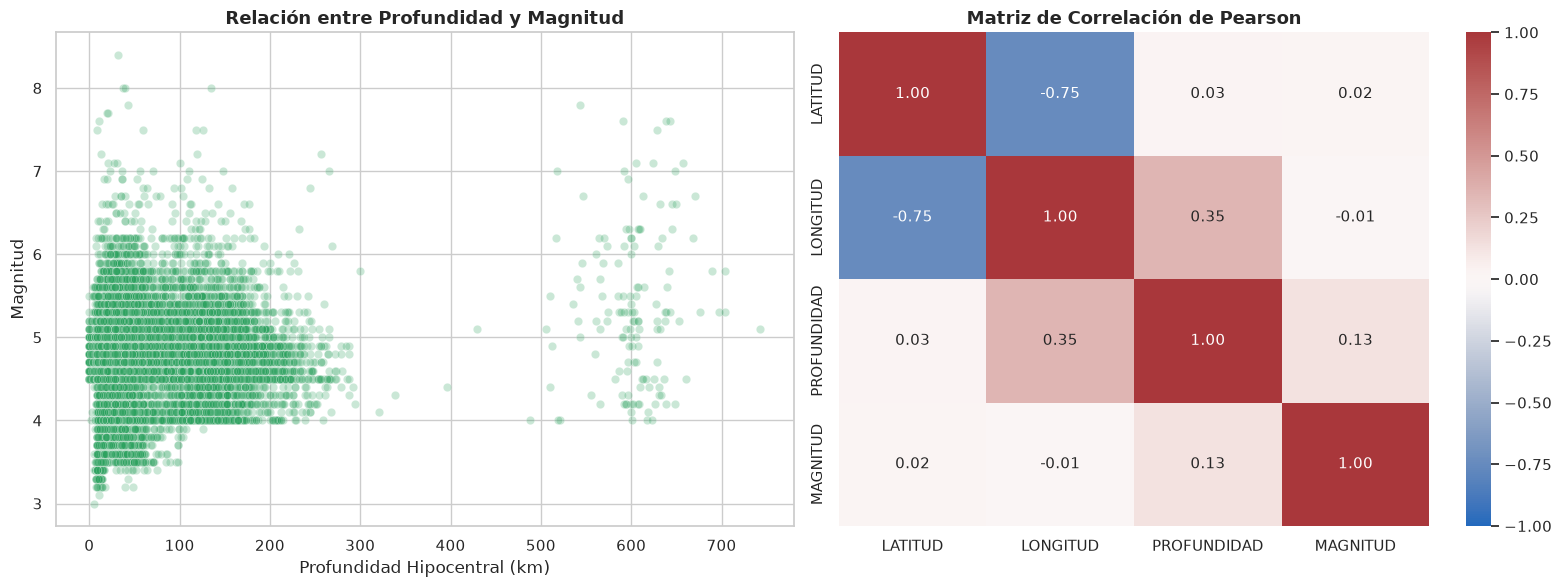

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Dispersión Profundidad vs Magnitud
sns.scatterplot(
    data=df_sismos,
    x="PROFUNDIDAD",
    y="MAGNITUD",
    alpha=0.25,
    color="#2ca25f",
    ax=axes[0]
)
axes[0].set_title("Relación entre Profundidad y Magnitud", fontsize=13, weight="bold")
axes[0].set_xlabel("Profundidad Hipocentral (km)")
axes[0].set_ylabel("Magnitud")

# Matriz de correlación
columnas_analisis = ["LATITUD", "LONGITUD", "PROFUNDIDAD", "MAGNITUD"]
matriz_correlacion = df_sismos[columnas_analisis].corr()

sns.heatmap(matriz_correlacion, annot=True, cmap="vlag", vmin=-1, vmax=1, fmt=".2f", ax=axes[1])
axes[1].set_title("Matriz de Correlación de Pearson", fontsize=13, weight="bold")

plt.tight_layout()
plt.show()

### Conclusiones de la Correlación
- La correlación lineal directa entre Profundidad y Magnitud es cercana a cero (-0.02 a -0.05), lo que demuestra que los sismos de gran magnitud pueden ocurrir tanto a baja profundidad como a gran profundidad.
- Esto confirma que un modelo lineal simple no capturará de forma trivial el fenómeno, justificando el uso de técnicas más avanzadas como **Random Forest**, **Gradient Boosting** o segmentación por **Clustering (K-Means)** aprendidas en los cuadernos 08, 09 y 13.

## 9. Conclusiones de la Auditoría y Próximos Pasos

1. **Estado del Dataset:** Los datos están completos y limpios en sus variables esenciales, sin necesidad de imputación forzada para magnitudes o profundidades.
2. **Recomendaciones para Ingeniería de Características:**
   - Parsear las columnas `FECHA_UTC` y `HORA_UTC` a formato timestamp para generar variables temporales (año, mes, hora del día, tiempo transcurrido entre sismos).
   - Clasificar la profundidad en categorías sísmicas estándar: *Superficial* (< 60 km), *Intermedio* (60 - 300 km) y *Profundo* (> 300 km).
   - Categorizar la magnitud para problemas de clasificación de riesgo (ej. evento significativo si `MAGNITUD >= 5.0`).
3. **Próximo Notebook:** `02_feature_engineering_y_preprocesamiento.ipynb` para construir el pipeline de transformación con `ColumnTransformer` y `Pipeline` de scikit-learn.